In [1]:
import sys
sys.path.append('../')

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import os

import audiofile
import librosa
import silero_vad

from tokenizers import ByteLevelBPETokenizer

from src.config.paths import CVUR_PATH, LIBRI_PATH, BILINGUAL_PATH
from src.config.asr import N_VOCAB, DISCARDED_SYMS
from src.core.speech.data import ASRDataset

# LibriSpeech

## Dataframe Structuring

In [4]:
def get_df(dir):    
    rows = []

    for speaker in os.listdir(dir):
        for passage in os.listdir(dir / speaker):
            with open(dir / speaker / passage / f'{speaker}-{passage}.trans.txt', 'r') as f:
                for line in f.read().splitlines():
                    words = line.split(' ')
                    sentence = words[0]
                    transcription = ' '.join(words[1:]).lower()

                    duration = audiofile.duration((dir / speaker / passage / sentence).__str__() + '.flac')
                    rows.append([speaker, passage, sentence, transcription, duration])


    return pd.DataFrame(rows, columns=['speaker_id', 'passage_id', 'sentence_id', 'transcription', 'duration'])        

In [5]:
for i in ['train-clean-100', 'test-clean', 'test-other']:
    get_df(LIBRI_PATH / i).to_parquet(LIBRI_PATH / f'{i}.parquet')

## Train-Test Ratio

In [6]:
train = pd.read_parquet(LIBRI_PATH / 'train-clean-100.parquet')
test = pd.read_parquet(LIBRI_PATH / 'test-clean.parquet')
test_other = pd.read_parquet(LIBRI_PATH / 'test-other.parquet')

In [7]:
test_dur = (len(test) + len(test_other))
test_dur / 2, test_dur / (test_dur + len(train)) / 2

(2779.5, 0.0815150448706669)

In [8]:
test_dur = test['duration'].sum() + test_other['duration'].sum()
test_dur / 3600 / 2, test_dur / (test_dur + train['duration'].sum()) / 2

(np.float64(5.37250704861111), np.float64(0.04825494157953091))

Mozilla should probably have a similar ratio

# Mozilla Common Voice 2026 Urdu

In [9]:
train = pd.read_csv((CVUR_PATH / 'train.tsv'), sep='\t')
test = pd.read_csv((CVUR_PATH / 'test.tsv'), sep='\t')
dev = pd.read_csv((CVUR_PATH / 'dev.tsv'), sep='\t')
other = pd.read_csv((CVUR_PATH / 'other.tsv'), sep='\t')

C:\Users\abi\AppData\Local\Temp\ipykernel_28184\2893445585.py:4: DtypeWarning: Columns (0: sentence_domain) have mixed types. Specify dtype option on import or set low_memory=False.
  other = pd.read_csv((CVUR_PATH / 'other.tsv'), sep='\t')


## Observations

### **1:** No logical unioning creates entire ```clips/``` dir

In [10]:
train

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,a0f8a9ee1690fefc5c61e0d739761cf69491a9632015da...,common_voice_ur_31949707.mp3,eb9317b52872b8aba134af7e4d927bf2620d6709a2d0f2...,نہ گنواؤ ناوک نیم کش دل ریزہ ریزہ گنوا دیا,NaN,2,0,twenties,male_masculine,NaN,NaN,ur,NaN
1,a0f8a9ee1690fefc5c61e0d739761cf69491a9632015da...,common_voice_ur_31886133.mp3,fda623e850e2803bcbc362343d7e35219e06af45d75c16...,علما کی فتویٰ سازی کے نتیجے میںیہ امور گویا حک...,NaN,6,0,twenties,male_masculine,NaN,NaN,ur,NaN
2,a0f8a9ee1690fefc5c61e0d739761cf69491a9632015da...,common_voice_ur_31949957.mp3,abb66ad53e21c75ce4662d89ed1c2dea9853d79117cfeb...,سچ کہتے ہو خودبین و خود آرا ہوں نہ کیوں ہوں,NaN,7,1,twenties,male_masculine,NaN,NaN,ur,NaN
3,fc0ab93844228cfa556e761b04b205368e45113d4baa5b...,common_voice_ur_31919214.mp3,ef4aed96cf008726edeaa5738f235ca12343a3a92364d1...,ویتنام کے سفیر کا اسلام باد چیمبر کامرس کا دورہ,NaN,2,0,twenties,female_feminine,NaN,NaN,ur,NaN
4,fc0ab93844228cfa556e761b04b205368e45113d4baa5b...,common_voice_ur_31870636.mp3,d1bd832b71c08ed3c1b1c0c034651ea1017deee7251968...,مذہبی اخلاقیات کی اساس مابعد الطبیعیاتی ہے۔,NaN,3,0,twenties,female_feminine,NaN,NaN,ur,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7293,82e51f2306d602019ceca69ff2978717ab7b05e612766b...,common_voice_ur_32033351.mp3,f75a7cead5a3a3ed57fee14442d160bd94fb8d75948f73...,مجھے نہیں پتا وہ کہاں ہے,NaN,2,0,twenties,female_feminine,NaN,NaN,ur,NaN
7294,82e51f2306d602019ceca69ff2978717ab7b05e612766b...,common_voice_ur_32033247.mp3,2721f2cfdaf1758b7815120450e19590a06061c105e741...,سر میں ٹھیلے پر فالودہ فروخت کرتا ہوں,NaN,2,0,twenties,female_feminine,NaN,NaN,ur,NaN
7295,82e51f2306d602019ceca69ff2978717ab7b05e612766b...,common_voice_ur_32032834.mp3,14a271dac2caa1daefd781edf416b030c9ec08d31fd4c8...,جاپانی لوگوں کی نفسیات,NaN,3,0,twenties,female_feminine,NaN,NaN,ur,NaN
7296,82e51f2306d602019ceca69ff2978717ab7b05e612766b...,common_voice_ur_32035551.mp3,3e57590c5b2e85fb9c2cbd886fe1d8b9c72c9620b77746...,جیسا ہمارا میڈیا ہے۔,NaN,4,0,twenties,female_feminine,NaN,NaN,ur,NaN


In [11]:
validated = pd.read_csv((CVUR_PATH / 'validated.tsv'), sep='\t')
invalidated = pd.read_csv((CVUR_PATH / 'invalidated.tsv'), sep='\t')

In [12]:
len(train), len(test), len(dev), len(other)

(7298, 5073, 5066, 171140)

In [13]:
len(validated), len(invalidated)

(63582, 10721)

In [14]:
should_be_all = sum([len(train), len(test), len(dev), len(other)])
actual_all = os.listdir(CVUR_PATH / 'clips')

len(actual_all), should_be_all

(250814, 188577)

In [15]:
len(actual_all) - should_be_all

62237

### Making my own ```all.tsv```

In [16]:
df = pd.concat([train, test, dev, other, validated, invalidated]).drop_duplicates().sort_values('path')

### **2:** Some are Lowkey Just Silence

Found this one while browsing the clips folder

In [17]:
df[df['path'] == 'common_voice_ur_32029754.mp3']

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
40556,3606b5a1ca688436612810d65531bd6166225193c405c9...,common_voice_ur_32029754.mp3,df335ffea2ee5f4dfbb20522cf39c60978b0b432245909...,تو سوال اٹھایا جاتا ہے: کیا احتساب نہ کیا جائے؟,NaN,0,1,twenties,male_masculine,NaN,NaN,ur,NaN


### **3:** High Upvotes and Downvotes don't tell you much

In [18]:
df.sort_values(['down_votes', 'up_votes'], ascending=False)

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
8044,d28ccd5c542932b1681ca275a884e13110114f9c2d0b34...,common_voice_ur_32058183.mp3,27246154534175c65955bcf6fdbaedce41d3e93b264b41...,جب پاکستانی قوم کو ایک ایسے ہی موقع کی تلاش تھی۔,NaN,0,36,twenties,female_feminine,clear|fluent,NaN,ur,NaN
3574,d28ccd5c542932b1681ca275a884e13110114f9c2d0b34...,common_voice_ur_31995283.mp3,606be670923f80c416b39a694b71bc42088a9a48bd54c4...,کرغزستان,NaN,9,33,twenties,female_feminine,clear|fluent,NaN,ur,NaN
8689,27a5db18ec44c558ffdba23861c92d7880f75aa68a5b8a...,common_voice_ur_38416785.mp3,f359ac61383da349680b9fc05e651e527be6ddebf5d0de...,اس بارے میں کوئی دوسری رائے نہیں مذہب بھی بزدل...,NaN,15,30,twenties,female_feminine,Native|norm|local|standarad,NaN,ur,NaN
5019,5e53d8511511b9345bf1e8840cbb8e6431341091f66f45...,common_voice_ur_32026685.mp3,8ef36f994eff0600be1f4961563f5b78c7b48e9f9f0c75...,وہ اجڑ گئے۔,NaN,12,28,twenties,male_masculine,Pakistani Native,NaN,ur,NaN
5883,34079be9f9ef68de28d960aa76f53aae052feeb0724efe...,common_voice_ur_32034596.mp3,40b270929535bd94e90a50b2cc4931588af8162ec2ad68...,پنجرہ کھلا ہے۔,NaN,8,26,NaN,NaN,Very generic and native,NaN,ur,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
171135,004b92683ab0431f6c9f83c99c583398d96b52f7a5ee0f...,common_voice_ur_49436536.mp3,19a643c04dad89e1b49241570f5c1ce43a4d70cd9fa00d...,ہمارے شہر آجاؤ صدا برسات رہتی ہے,NaN,0,0,fourties,NaN,NaN,NaN,ur,NaN
171136,004b92683ab0431f6c9f83c99c583398d96b52f7a5ee0f...,common_voice_ur_49436537.mp3,1ade8c443f22b1e593bde28e8e0147899a3e142cafd6e6...,شادی بھی ان کی بمبئی کی اپر کلاس پارسی فیملی م...,NaN,0,0,fourties,NaN,NaN,NaN,ur,NaN
171137,004b92683ab0431f6c9f83c99c583398d96b52f7a5ee0f...,common_voice_ur_49436538.mp3,194189a39823f61264b48756c564c22780a6baee90bdee...,یے لڑکا ہے,NaN,0,0,fourties,NaN,NaN,NaN,ur,NaN
171138,004b92683ab0431f6c9f83c99c583398d96b52f7a5ee0f...,common_voice_ur_49436539.mp3,194a0d919a94dc695f0e236469259aa41fda593104dce2...,پنجاب ہاؤسوں کا قبضہ واگزار کرا لیا جاتا۔,NaN,0,0,fourties,NaN,NaN,NaN,ur,NaN


common_voice_ur_32058183.mp3 - 0|36 - Literally no audio in this clip <br>
common_voice_ur_31995283.mp3 - 9|33 - JUST silence, again, but it has UPVOTES? <br>
common_voice_ur_38416785.mp3 - 15|30 - Skipped a word <br>
common_voice_ur_32026685.mp3 - 12|28 - LITERALLY JUST SILENCE


### **4:** No immediately obvious silence for ```df['up_votes'] > df['down_votes]```

In [19]:
df[df['up_votes'] > df['down_votes']].sort_values(['down_votes', 'up_votes'], ascending=True)

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...,common_voice_ur_31789690.mp3,7c0140d3ad015cf00e44762f00c4651335e308fe6f5e52...,کبھی بھی پیرا شوٹ سے چھلانگ لگانا پسند نہیں کر...,NaN,1,0,twenties,male_masculine,NaN,NaN,ur,NaN
1,967d14f12a44fa62391a22bdaaa21be6d657237b233163...,common_voice_ur_31799503.mp3,8fc3654a0412fc104e3f53680f786601ec9c38368a45be...,وہ منیجر کے کمرے میں گیا,NaN,1,0,twenties,male_masculine,NaN,NaN,ur,NaN
2,9a2de47f11bea8ec48b7bf5b03f2ca13e81cdba7db0eb8...,common_voice_ur_31801326.mp3,85f17859616539607840c41f8c912c5d25b265228a2219...,ایک تازہ ترین خبر کے مطابق ايشيا کے تیز ترین س...,NaN,1,0,NaN,NaN,NaN,NaN,ur,NaN
3,a866e6e3e272389978bca1c0b9499268d90574792370df...,common_voice_ur_31810974.mp3,ad3b36229b4c7ca034f5338e260d4e980030b2c23b0f9c...,پوری دنیا میں صرف پاکستان میں ہی ہیں ۔,NaN,1,0,twenties,male_masculine,NaN,NaN,ur,NaN
7,00e77ea0f4da381325ffea4b940d26c2805f797a7bf986...,common_voice_ur_31812217.mp3,9e099f345f1d425fb378c14f8a72f8d6c2843741aef7d4...,ملتان شوبز ڈیسک امریکا کی مقبول ترین فیشن ماڈل...,NaN,1,0,twenties,male_masculine,NaN,NaN,ur,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29211,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31970749.mp3,ae22332aaabc9c7f1c5751680daf77092819d4f1817e77...,اب عوام کو حقیقت پسندی کے ساتھ فیصلہ کرنا ہو گا۔,NaN,39,15,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
28988,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31974337.mp3,e72877dd0b6462b2ec21b1bbc046be5f2979d2a8d67db9...,پی ایس ایل فائنل دونوں ٹیموں کی فائنل پریکٹسٹر...,NaN,24,18,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
1672,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31972267.mp3,ce3c4b548ee9db1fcf55e448b0ea333a2520b6f51448b7...,جس نے ملکی قیادت پر کئی بار شب خون مارا ہو,NaN,27,18,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
29008,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31974265.mp3,ce675fc85df0c441029363e62a19ba769f96120a43b137...,اجتک کئئ لوگ یہ بکواس کہتے ھیں کہ عمران خان کی...,NaN,33,18,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN


common_voice_ur_31789690.mp3 - 1|0 - Perfectly Fine <br>
common_voice_ur_31799503.mp3 - 1|0 - Perfectly Fine


### **5:** There are still faulty recordings, some more so than others

In [20]:
df[df['up_votes'] > df['down_votes']].sort_values(['down_votes', 'up_votes'], ascending=False)

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
29008,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31974265.mp3,ce675fc85df0c441029363e62a19ba769f96120a43b137...,اجتک کئئ لوگ یہ بکواس کہتے ھیں کہ عمران خان کی...,NaN,33,18,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
29085,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_32029718.mp3,d571d4b2f07fcc70be3875a0783af41144def3ed37c6a0...,لاہورنمائندہ شوبز بھارتی اداکارہ زينت امان بھا...,NaN,33,18,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
1672,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31972267.mp3,ce3c4b548ee9db1fcf55e448b0ea333a2520b6f51448b7...,جس نے ملکی قیادت پر کئی بار شب خون مارا ہو,NaN,27,18,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
28988,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31974337.mp3,e72877dd0b6462b2ec21b1bbc046be5f2979d2a8d67db9...,پی ایس ایل فائنل دونوں ٹیموں کی فائنل پریکٹسٹر...,NaN,24,18,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
29211,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31970749.mp3,ae22332aaabc9c7f1c5751680daf77092819d4f1817e77...,اب عوام کو حقیقت پسندی کے ساتھ فیصلہ کرنا ہو گا۔,NaN,39,15,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
169736,4d5605d90e608c71231d644d911a468dfcd2dad0c772f5...,common_voice_ur_41198566.mp3,13bc57811137e5cb05cbcfd0315b07b19f4b7c2eeccb11...,کرنے کے الزام میں مسافر,NaN,1,0,twenties,NaN,NaN,NaN,ur,NaN
169742,4d5605d90e608c71231d644d911a468dfcd2dad0c772f5...,common_voice_ur_41198572.mp3,17fdd4d594616d4576dbb3d0f572f0da9806dd5109e1cf...,شہد کے استعمال پر ذرہ برابر فرق نہ پڑا۔,NaN,1,0,twenties,NaN,NaN,NaN,ur,NaN
170378,0ae0a93f58aeecf94f2237f8cbb0c7b6b4aa5cca9d50ed...,common_voice_ur_42442127.mp3,17be73326f0b2dfd0970eb2dbfbc3066cb7b1ca4920473...,کیا کیا کہانیاںان شاموںسے منسلک ہیں۔,NaN,1,0,twenties,NaN,NaN,NaN,ur,NaN
170453,272a47157a17b832cfe4e680b556f35740248e68824223...,common_voice_ur_42584323.mp3,18ed2c69436dcb0c0b6407fe9017cf1a542c6e30f92568...,اس وقت ویسی ہی قربانی اور جذبے کی ضرورت ہے,NaN,1,0,fourties,NaN,NaN,NaN,ur,NaN


common_voice_ur_31974265.mp3 - 33|18 - She reads the first half twice <br>
common_voice_ur_32029718.mp3 - 33|18 - She initially says *adaarka* on accident instead of *adakaara* before correcting herself <br>
common_voice_ur_31972267.mp3 - 27|18 - Mispronounced the last *ho* as *ha*

### **6:** A %age approach may eliminate a fair few of these cases

In [21]:
my_validated = df[(df['down_votes'] / (df['up_votes'] + df['down_votes'])) < 0.1]
my_validated.sort_values(['down_votes', 'up_votes'], ascending=False)

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
29096,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31970101.mp3,a332f1fab5c954b7b45aed6e5fd933b67e74bb2b0af92f...,اس سادہ پہ کونہ نہ مر جائے اے خدا,NaN,51,3,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
48921,d28ccd5c542932b1681ca275a884e13110114f9c2d0b34...,common_voice_ur_31995083.mp3,5e5c4270048da09aef15e3f6b7017c41680d13018e54b7...,انڈیا کی بھی نظریں تھیں۔,NaN,51,3,twenties,female_feminine,clear|fluent,NaN,ur,NaN
29066,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31971420.mp3,bcafa2923556018244f02e4c13c2dffaa1192d862086fd...,میں ان سوالات کی گرفت میں ہوں۔,NaN,48,3,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
28969,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31979986.mp3,4f4be9713de2109b5fe7531a8260e0914845fd34dd422f...,بڑے آپریشن کی ضرورت ہے,NaN,48,3,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
29296,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31981381.mp3,6b4eb75ccb6efb25540265f0b6e066906837470ffe20f3...,ایک دن کے کھیل کا ماہر,NaN,48,3,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
169736,4d5605d90e608c71231d644d911a468dfcd2dad0c772f5...,common_voice_ur_41198566.mp3,13bc57811137e5cb05cbcfd0315b07b19f4b7c2eeccb11...,کرنے کے الزام میں مسافر,NaN,1,0,twenties,NaN,NaN,NaN,ur,NaN
169742,4d5605d90e608c71231d644d911a468dfcd2dad0c772f5...,common_voice_ur_41198572.mp3,17fdd4d594616d4576dbb3d0f572f0da9806dd5109e1cf...,شہد کے استعمال پر ذرہ برابر فرق نہ پڑا۔,NaN,1,0,twenties,NaN,NaN,NaN,ur,NaN
170378,0ae0a93f58aeecf94f2237f8cbb0c7b6b4aa5cca9d50ed...,common_voice_ur_42442127.mp3,17be73326f0b2dfd0970eb2dbfbc3066cb7b1ca4920473...,کیا کیا کہانیاںان شاموںسے منسلک ہیں۔,NaN,1,0,twenties,NaN,NaN,NaN,ur,NaN
170453,272a47157a17b832cfe4e680b556f35740248e68824223...,common_voice_ur_42584323.mp3,18ed2c69436dcb0c0b6407fe9017cf1a542c6e30f92568...,اس وقت ویسی ہی قربانی اور جذبے کی ضرورت ہے,NaN,1,0,fourties,NaN,NaN,NaN,ur,NaN


common_voice_ur_31970101.mp3 - 51|3 - Perfectly Fine <br>
common_voice_ur_31995083.mp3 - 51|3 - Perfectly Fine

### **7:** Most of the data is low engagement and unreliable

This distribution is also true for the general unfilitered set, this is not unique to our criteria

<Axes: >

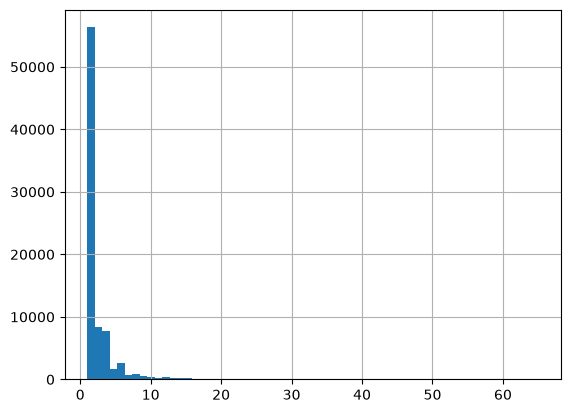

In [22]:
my_validated['engagement'] = my_validated['up_votes'] + my_validated['down_votes']
my_validated['engagement'].hist(bins=60)

### **8:** Metadata leaking into Cells due to faulty formatting

In [23]:
pd.concat([
    dev[dev['sentence'].apply(lambda x: '1' in x)],
    other[other['sentence'].apply(lambda x: '1' in x)]
])

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
1756,9b429f257f586530550730449045b59f09cf6f278e7e17...,common_voice_ur_26630593.mp3,10d510e12ca4a24f5b9250854a8f899883f6a503da77ef...,میٹھا انڈا تو کبھی نہیں سنا ۔\t\t2\t0\tthirtie...,NaN,2,1,thirties,female_feminine,NaN,NaN,ur,NaN
5749,9ce048358c8acb42f2cf1e2e117111bd9517e2e8d00be1...,common_voice_ur_31956978.mp3,10d510e12ca4a24f5b9250854a8f899883f6a503da77ef...,میٹھا انڈا تو کبھی نہیں سنا ۔\t\t1\t0\ttwentie...,NaN,1,0,twenties,female_feminine,NaN,NaN,ur,NaN
11434,09f3d501fd60a35afa43ea5fbef1f8feb7736f575e1dff...,common_voice_ur_31976591.mp3,10d510e12ca4a24f5b9250854a8f899883f6a503da77ef...,میٹھا انڈا تو کبھی نہیں سنا ۔\t\t0\t0\ttwentie...,NaN,1,0,twenties,male_masculine,NaN,NaN,ur,NaN
25448,199fc9b346e75cd63a9d45a0dcfdc26b47ac6bfca66bdb...,common_voice_ur_32006537.mp3,10d510e12ca4a24f5b9250854a8f899883f6a503da77ef...,میٹھا انڈا تو کبھی نہیں سنا ۔\t\t0\t0\ttwentie...,NaN,0,0,twenties,male_masculine,NaN,NaN,ur,NaN
43266,0c778d5bb707ddbc23386e8c4e005faf35b3ba605f08ca...,common_voice_ur_32033745.mp3,10d510e12ca4a24f5b9250854a8f899883f6a503da77ef...,میٹھا انڈا تو کبھی نہیں سنا ۔\t\t0\t0\ttwentie...,NaN,0,0,twenties,male_masculine,NaN,NaN,ur,NaN
43347,c2d422a5c860a0752ed1cfa6e03f396f86a6a1bf2ebd6c...,common_voice_ur_32033878.mp3,10d510e12ca4a24f5b9250854a8f899883f6a503da77ef...,میٹھا انڈا تو کبھی نہیں سنا ۔\t\t0\t0\ttwentie...,NaN,1,0,NaN,NaN,NaN,NaN,ur,NaN


Some of these cells are FRIED, like wtf do u mean the sentence is:

```میٹھا انڈا تو کبھی نہیں سنا ۔		0	0	twenties	male_masculine			ur	
4bcd95bd3ac08d21c4db2a5d08a697e19c01489a007160be12213df5bf7f29f3f747000a01becd3eb1861502d912fc55aff9329dc3532cf0da6c388200865aa6	common_voice_ur_32006540.mp3	100a16618732bd6d255776d3321390eee0063677df7347e5fc7933f94d47f028	جنہیں حاصل کرنا		0	0	twenties	male_masculine			ur	
4bcd95bd3ac08d21c4db2a5d08a697e19c01489a007160be12213df5bf7f29f...```

This doesnt happen in train or test

In [24]:
pd.concat([
    train[train['sentence'].apply(lambda x: '1' in x)],
    test[test['sentence'].apply(lambda x: '1' in x)]
])

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment


### **9:** A tiny porportion of Samples Have Romanized Transcriptions

In [25]:
df[df['sentence'].apply(lambda x: 'a' in x) & ~ df['sentence'].apply(lambda x: '1' in x)]

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
63046,eca2caee062aa3326a2bdfab578013b1925ba7b12b6f2e...,common_voice_ur_32547994.mp3,024499ae621c62dc24531a6db4e281a945dc73af3d9c39...,Kiray K Ghar Thay Badalty Rahay,NaN,0,0,thirties,male_masculine,Pakistani,NaN,ur,NaN
64023,f880309cae520501705ea7ce2aead1ea6c994633b678b7...,common_voice_ur_35174926.mp3,4018aa292d1f820e727a2b3fb6117d0c8b8282a1dee783...,aala,NaN,1,0,NaN,NaN,NaN,NaN,ur,NaN
64049,06ce7866873ffc9bc5412a1c006e0b966349b08764b771...,common_voice_ur_36859722.mp3,530eec316da29af994030adb6055999eaa84d6951b3fa1...,buht achi bat kahi he,NaN,0,0,NaN,NaN,NaN,NaN,ur,NaN
64702,9235fe0df77036bbde8fd692b1bc0067f6c6714101b4f8...,common_voice_ur_38409203.mp3,759f3bec76d461c909bb7bcf5a704a3fb454e6da8fccf0...,Muhabbat Adawat Wafa Berukhi,NaN,1,0,twenties,female_feminine,NaN,NaN,ur,NaN
1984,16c5d507d93d398d3df82ffd4b3c27abdfa9d0756c47e0...,common_voice_ur_38409557.mp3,2257a92e9c327370780ec418ee0f27e2ee1e26c7eeec11...,Muqaddar Main Chalna Tha Chaltay Rahay,NaN,2,0,twenties,male_masculine,NaN,NaN,ur,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140989,7fa5979454d028c910c50035dd9b9e2cd43f0c73c6aa83...,common_voice_ur_41154887.mp3,530eec316da29af994030adb6055999eaa84d6951b3fa1...,buht achi bat kahi he,NaN,0,0,twenties,NaN,NaN,NaN,ur,NaN
142329,4587e0bf54289816083bb8c408416a58a4e3d686df878f...,common_voice_ur_41156668.mp3,759f3bec76d461c909bb7bcf5a704a3fb454e6da8fccf0...,Muhabbat Adawat Wafa Berukhi,NaN,0,0,twenties,NaN,An Islamabad accent with a hint of Punjabi dia...,NaN,ur,NaN
147173,50be47c0ccf3fa5d0bef58d3c48c6b14a75e55dfa343b3...,common_voice_ur_41163506.mp3,908fa77b00fe27ad4d554a93dae512e3f8adc0cb526b4a...,Musafir K Rastay Badaltay Rahay,NaN,0,0,twenties,NaN,Pakistani accent,NaN,ur,NaN
154957,cdf514b2b88feb6de06188a69b0954636abe89f4b94150...,common_voice_ur_41173536.mp3,024499ae621c62dc24531a6db4e281a945dc73af3d9c39...,Kiray K Ghar Thay Badalty Rahay,NaN,0,0,twenties,NaN,NaN,NaN,ur,NaN


## My Hypothesis

Observation 8 accounts for Observation 1

### Dev Set Corruption Tracking

Since this set only has one corrupted row, its a great place to start

In [26]:
corrupted = dev[dev['sentence'].apply(lambda x: '1' in x)].index.values
left = {i - 1 for i in corrupted}
right = {i + 1 for i in corrupted}

dev.iloc[sorted(left.union(corrupted, right))]

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
1755,9b429f257f586530550730449045b59f09cf6f278e7e17...,common_voice_ur_26630592.mp3,06be82145593e11580108de7363c00e1ceb2c503d6cc7d...,مغربی ارجنٹینا کا موسم گرما کا وقت,NaN,2,1,thirties,female_feminine,NaN,NaN,ur,NaN
1756,9b429f257f586530550730449045b59f09cf6f278e7e17...,common_voice_ur_26630593.mp3,10d510e12ca4a24f5b9250854a8f899883f6a503da77ef...,میٹھا انڈا تو کبھی نہیں سنا ۔\t\t2\t0\tthirtie...,NaN,2,1,thirties,female_feminine,NaN,NaN,ur,NaN
1757,9b429f257f586530550730449045b59f09cf6f278e7e17...,common_voice_ur_26630038.mp3,0c39982fa517b27e8af96860910178aecf93859bdcd2ad...,اب بھی وہی قائم ہیں۔,NaN,2,0,thirties,female_feminine,NaN,NaN,ur,NaN


In [27]:
extracted = []
i = 0
with open(CVUR_PATH / 'dev.tsv') as f:
    for i in range(corrupted[0]):
        extracted = f.readline()
        i+=1
i, extracted

(1756,
 '9b429f257f586530550730449045b59f09cf6f278e7e170f4b93de7114c708d938d51214275a8be24c9f6459e65e792b3a6be8c4fcb6332f2c1a768ed3c5af40\tcommon_voice_ur_26630128.mp3\t009dfd053887b976fd7447fc46e3cb3fa5eb83d5a7c892131c921fa848e49be2\tمکمل خاموشی پھر ہلکی سی آہٹ سنائی دیتی ہے\t\t2\t0\tthirties\tfemale_feminine\t\t\tur\t\n')

In [28]:
extracted.split('\t')

['9b429f257f586530550730449045b59f09cf6f278e7e170f4b93de7114c708d938d51214275a8be24c9f6459e65e792b3a6be8c4fcb6332f2c1a768ed3c5af40',
 'common_voice_ur_26630128.mp3',
 '009dfd053887b976fd7447fc46e3cb3fa5eb83d5a7c892131c921fa848e49be2',
 'مکمل خاموشی پھر ہلکی سی آہٹ سنائی دیتی ہے',
 '',
 '2',
 '0',
 'thirties',
 'female_feminine',
 '',
 '',
 'ur',
 '\n']

In [29]:
extracted = []
with open(CVUR_PATH / 'dev.tsv') as f:
    sent = f.readline()
    while sent:
        extracted.append(sent.split('\t'))
        sent = f.readline()
len(extracted), len(dev)

(5074, 5066)

In [30]:
dev_manual = pd.DataFrame(extracted[1:], columns=extracted[0])
dev_manual[dev_manual['sentence'].apply(lambda x: '1' in  x)]

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment\n


So its just some Pandas error?

### Other Set

In [31]:
extracted = []
with open(CVUR_PATH / 'other.tsv') as f:
    sent = f.readline()
    while sent:
        extracted.append(sent.split('\t'))
        sent = f.readline()
len(extracted), len(other)

(172228, 171140)

In [32]:
other_manual = pd.DataFrame(extracted[1:], columns=extracted[0])
other_manual[other_manual['sentence'].apply(lambda x: '1' in  x)]

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment\n


In [33]:
other_manual['up_votes'] = other_manual['up_votes'].astype(int)
other_manual['down_votes'] = other_manual['down_votes'].astype(int)

dev_manual['up_votes'] = dev_manual['up_votes'].astype(int)
dev_manual['down_votes'] = dev_manual['down_votes'].astype(int)

## The Data I Used

### Starting Criteria

In [34]:
df = pd.concat([
    train[train['sentence'].apply(lambda x: 'a' not in x)],
    test[test['sentence'].apply(lambda x: 'a' not in x)],
    dev_manual[dev_manual['sentence'].apply(lambda x: 'a' not in x)],
    other_manual[other_manual['sentence'].apply(lambda x: 'a' not in x)],
])
my_validated = df[((df['up_votes'] / (df['up_votes'] + df['down_votes'])) > 0.7) ]
my_validated.sort_values(['down_votes', 'up_votes'], ascending=False)

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,segment\n
1622,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31997928.mp3,82f3791bfb04610c576f096edadcb4be0de59b305b42af...,برصغیر کی پرانی روایت یہی رہی ہے۔,NaN,30,12,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN,NaN
1662,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31971055.mp3,b0a307688b8fe87fd354c49b2489532bb55d8b474ab77d...,یہ سب لکھ سکتے ہیں؟,NaN,24,9,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN,NaN
1698,8346e46ba238dbfdb3d0774bdd4047d9146d0178244627...,common_voice_ur_31974136.mp3,ee8304715cc71c7179a72a9c3458a9c04c35107c77e320...,پیپلزپارٹی کے پاس کو ئی متبادل ہے؟,NaN,33,6,twenties,female_feminine,Karachi|Islamabadi,NaN,ur,NaN,NaN
593,5e53d8511511b9345bf1e8840cbb8e6431341091f66f45...,common_voice_ur_32017843.mp3,eb11d4bca6027ad68e14b228a3c247a0cbd5f18729792a...,پانچواں مسئلہ یہ پیدا ہوتا ہے کہ حکمران اگر دی...,,24,6,twenties,male_masculine,Pakistani Native,,ur,NaN,\n
3992,102eaa418ecd2264dfddf6e7b361ade94e3d3540450b82...,common_voice_ur_38482946.mp3,6ea6a9df061f2a37ca7d1f2b10a7eaeb393e262cb22f0a...,رشک ہے آسایشِ اربابِ غفلت پر اسد!,NaN,21,6,twenties,male_masculine,Pakistani|Karachi,NaN,ur,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170823,4d5605d90e608c71231d644d911a468dfcd2dad0c772f5...,common_voice_ur_41198566.mp3,13bc57811137e5cb05cbcfd0315b07b19f4b7c2eeccb11...,کرنے کے الزام میں مسافر,,1,0,twenties,,,,ur,NaN,\n
170829,4d5605d90e608c71231d644d911a468dfcd2dad0c772f5...,common_voice_ur_41198572.mp3,17fdd4d594616d4576dbb3d0f572f0da9806dd5109e1cf...,شہد کے استعمال پر ذرہ برابر فرق نہ پڑا۔,,1,0,twenties,,,,ur,NaN,\n
171465,0ae0a93f58aeecf94f2237f8cbb0c7b6b4aa5cca9d50ed...,common_voice_ur_42442127.mp3,17be73326f0b2dfd0970eb2dbfbc3066cb7b1ca4920473...,کیا کیا کہانیاںان شاموںسے منسلک ہیں۔,,1,0,twenties,,,,ur,NaN,\n
171540,272a47157a17b832cfe4e680b556f35740248e68824223...,common_voice_ur_42584323.mp3,18ed2c69436dcb0c0b6407fe9017cf1a542c6e30f92568...,اس وقت ویسی ہی قربانی اور جذبے کی ضرورت ہے,,1,0,fourties,,,,ur,NaN,\n


### Duration Analysis

In [35]:
CLIPS_PATH = CVUR_PATH / 'clips'
my_validated['duration'] = (CLIPS_PATH / my_validated['path']).apply(audiofile.duration)

manually calculating with soundfile took over 9 minutes, audiofile.duration took 7.5min and also required less code. (could be caching)

In [36]:
f'{my_validated['duration'].sum()/3600:.2f} hours of recorded Urdu Speech'

'49.81 hours of recorded Urdu Speech'

In [37]:
my_validated['duration'].max(), my_validated['duration'].mean(), my_validated['duration'].min() 

(np.float64(19.9155), np.float64(4.254713239001733), np.float64(0.5475))

In [38]:
my_validated = my_validated.reset_index()[['path', 'duration', 'sentence', 'up_votes', 'down_votes', 'age', 'gender']]
my_validated

,path,duration,sentence,up_votes,down_votes,age,gender
0,common_voice_ur_31949707.mp3,6.1275,نہ گنواؤ ناوک نیم کش دل ریزہ ریزہ گنوا دیا,2,0,twenties,male_masculine
1,common_voice_ur_31886133.mp3,9.4755,علما کی فتویٰ سازی کے نتیجے میںیہ امور گویا حک...,6,0,twenties,male_masculine
2,common_voice_ur_31949957.mp3,6.1275,سچ کہتے ہو خودبین و خود آرا ہوں نہ کیوں ہوں,7,1,twenties,male_masculine
3,common_voice_ur_31919214.mp3,4.1835,ویتنام کے سفیر کا اسلام باد چیمبر کامرس کا دورہ,2,0,twenties,female_feminine
4,common_voice_ur_31870636.mp3,4.3635,مذہبی اخلاقیات کی اساس مابعد الطبیعیاتی ہے۔,3,0,twenties,female_feminine
...,...,...,...,...,...,...,...
42138,common_voice_ur_41198566.mp3,2.6355,کرنے کے الزام میں مسافر,1,0,twenties,
42139,common_voice_ur_41198572.mp3,3.7875,شہد کے استعمال پر ذرہ برابر فرق نہ پڑا۔,1,0,twenties,
42140,common_voice_ur_42442127.mp3,4.3275,کیا کیا کہانیاںان شاموںسے منسلک ہیں۔,1,0,twenties,
42141,common_voice_ur_42584323.mp3,4.9755,اس وقت ویسی ہی قربانی اور جذبے کی ضرورت ہے,1,0,fourties,


### Silence Check

In [39]:
model = silero_vad.load_silero_vad()

In [40]:
signal, sr = audiofile.read(r"E:\Coding\Projects\btyi\data\mozilla-cv26-ur\clips\common_voice_ur_32029754.mp3")
silero_vad.get_speech_timestamps(signal, model, return_seconds=True)

[]

In [41]:
signal, sr = audiofile.read(r"E:\Coding\Projects\btyi\data\mozilla-cv26-ur\clips\common_voice_ur_32029755.mp3")
silero_vad.get_speech_timestamps(signal, model, return_seconds=True)

[{'start': 2.4, 'end': 5.7},
 {'start': 5.9, 'end': 6.8},
 {'start': 6.9, 'end': 7.5},
 {'start': 7.6, 'end': 8.0}]

In [ ]:
i = 0
N = len(my_validated)

def is_silence(dir):
    global i
    i += 1
    print(f'\r{i}/{N}', end='')    
    signal, sr = audiofile.read(CVUR_PATH / 'clips' / dir)
    if sr != 16_000:
        signal = librosa.resample(signal, orig_sr=sr, target_sr=16_000)
    return 0 == len(silero_vad.get_speech_timestamps(signal, model, return_seconds=True))


model = silero_vad.load_silero_vad()
my_validated['is_silence'] = my_validated['path'].apply(is_silence)
my_validated.to_csv(CVUR_PATH / 'cleaned_set.tsv', sep='\t')

35314/42143

In [ ]:
my_validated[my_validated['is_silence']]

common_voice_ur_31827067.mp3 - 2|0 - Completely Silent <br>
common_voice_ur_31827088.mp3 - 2|0 - Completely Silent <br>
common_voice_ur_31827193.mp3 - 2|0 - Completely Silent

In [ ]:
my_validated[my_validated['is_silence']].sort_values('up_votes', ascending=False)

common_voice_ur_31901860.mp3 - 8|0 - Completely Silent <br>
common_voice_ur_31901635.mp3 - 6|2 - Completely Silent <br>
common_voice_ur_32027582.mp3 - 6|2 - Completely Silent <br>

In [ ]:
my_validated = my_validated[~my_validated['is_silence']].reset_index(drop=True)
my_validated = my_validated[['path', 'duration', 'sentence', 'up_votes', 'down_votes', 'age', 'gender']]

### Saving

In [ ]:
my_validated.to_parquet(CVUR_PATH / 'cleaned_set.parquet')

## Train-Test Split

In [ ]:
my_validated = pd.read_parquet(CVUR_PATH / 'cleaned_set.parquet')

The union of test and test-other split for LibriSpeech is about 
- ~5.6k samples (16% of all available Libri samples)
- ~10.75hrs (9.7% of all available Libri clips)


**Note:**
CVUR has more samples but they are cumulatively shorter in terms of duration, so what that means for training is language bias. This is because weight updations are gonna occur per sample.
This is why we can't just concat them and will use a roundrobin with circular arrays for balanced training where appropriate.
So, in this section, we won't be concerning ourselves with sample level details.

Here, we focus solely on balancing the language representation in the test set in terms of raw duration

In [ ]:
my_validated[my_validated['sentence'].apply(lambda x: 'a' in x)]

In [ ]:
test = my_validated.sample(frac=0.11).reset_index()
train = my_validated[~my_validated['path'].isin(test['path'])].reset_index(drop=True)

test.to_parquet(CVUR_PATH / 'cleaned_test.parquet')
train.to_parquet(CVUR_PATH / 'cleaned_train.parquet')

N = test['duration'].sum() + train['duration'].sum()
print(f'Test: {test['duration'].sum()/3600:.2f}hrs ({test['duration'].sum() / N :.2%})')
print(f'Train: {train['duration'].sum()/3600:.2f}hrs ({train['duration'].sum() / N :.2%})')

# Data Standardization

In [ ]:
cvur_train = pd.read_parquet(CVUR_PATH / 'cleaned_train.parquet')
cvur_test = pd.read_parquet(CVUR_PATH / 'cleaned_test.parquet')

libri_train = pd.read_parquet(LIBRI_PATH / 'train-clean-100.parquet')
libri_test = pd.read_parquet(LIBRI_PATH / 'test-clean.parquet')
libri_testother = pd.read_parquet(LIBRI_PATH / 'test-other.parquet')

## Standardizing Columns

In [ ]:
cvur_train = cvur_train.rename({'path': 'file', 'sentence': 'transcription'}, axis=1)[['file', 'transcription', 'duration']]
cvur_test = cvur_test.rename({'path': 'file', 'sentence': 'transcription'}, axis=1)[['file', 'transcription', 'duration']]

cvur_train['origin'] = 'mcv-urdu'
cvur_test['origin'] = 'mcv-urdu'

cvur_train['speaker_id'] = None
cvur_train['passage_id'] = None

cvur_test['speaker_id'] = None
cvur_test['passage_id'] = None


libri_train['origin'] = 'libri-train-clean-100h'
libri_test['origin'] = 'libri-test-clean'
libri_testother['origin'] = 'libri-test-other'

libri_train = libri_train.rename({'sentence_id': 'file'}, axis=1)[['file', 'transcription', 'origin', 'speaker_id', 'passage_id', 'duration']]
libri_test = libri_test.rename({'sentence_id': 'file'}, axis=1)[['file', 'transcription', 'origin', 'speaker_id', 'passage_id', 'duration']]
libri_testother = libri_testother.rename({'sentence_id': 'file'}, axis=1)[['file', 'transcription', 'origin', 'speaker_id', 'passage_id', 'duration']]

libri_train['file'] = libri_train['file'].apply(lambda x: x + '.flac')
libri_test['file'] = libri_test['file'].apply(lambda x: x + '.flac')
libri_testother['file'] = libri_testother['file'].apply(lambda x: x + '.flac')

## Normalizing

In [ ]:
def normalize(txt):
    return ''.join(i for i in txt.lower() if i not in DISCARDED_SYMS)

libri_train['transcription'] = libri_train['transcription'].apply(normalize)
libri_test['transcription'] = libri_test['transcription'].apply(normalize)
libri_testother['transcription'] = libri_testother['transcription'].apply(normalize)

cvur_train['transcription'] = cvur_train['transcription'].apply(normalize)
cvur_test['transcription'] = cvur_test['transcription'].apply(normalize)


## Saving Cleaned But FR Clean this Time

In [ ]:
cvur_train.to_parquet(BILINGUAL_PATH / 'cvur-train.parquet')
cvur_test.to_parquet(BILINGUAL_PATH / 'cvur-test.parquet')

libri_train.to_parquet(BILINGUAL_PATH / 'libri-train.parquet')
libri_test.to_parquet(BILINGUAL_PATH / 'libri-test.parquet')
libri_testother.to_parquet(BILINGUAL_PATH / 'libri-test-other.parquet')

## Data Summary

In [ ]:
train = pd.concat([libri_train, cvur_train])
test = pd.concat([libri_test, libri_testother, cvur_test])

In [ ]:
train.groupby('origin')['duration'].sum() / 3600

In [ ]:
test.groupby('origin')['duration'].sum() / 3600

## Tokenizer

In [ ]:
[
    (i, idx)
    for idx,i in enumerate(train['transcription'].to_list())
    if 'f63187c62243ac7a9c0c4633a9fe337660a466dfcee946d404fe125174c1c9444b1dcffae277b4a369008346d464a3c95372502469a24c3e45cc61bfd9445eac' in i
]

In [ ]:
train.iloc[43953]

In [ ]:
cvur_train[cvur_train['transcription'].apply(lambda x: 'a' in x)]

In [ ]:
with open(BILINGUAL_PATH / 'flattend_corpora.txt', 'w') as f:
    f.write(
        '\n'.join(
            i.lower() for i in train['transcription'].to_list()
        )
    )

In [ ]:
tokenizer = ByteLevelBPETokenizer()
tokenizer.train(
    files=[(BILINGUAL_PATH / 'flattend_corpora.txt').__str__()],
    vocab_size= N_VOCAB
)

In [ ]:
t = tokenizer.encode('کل جب she met you at the مسجد she seemed fine')
print(t.ids, t.tokens, sep='\n')

# DataLoaders

In [ ]:
cvur_train = pd.read_parquet(BILINGUAL_PATH / 'cvur-train.parquet')
cvur_test = pd.read_parquet(BILINGUAL_PATH / 'cvur-test.parquet')

libri_train = pd.read_parquet(BILINGUAL_PATH/ 'libri-train.parquet')
libri_test = pd.read_parquet(BILINGUAL_PATH / 'libri-test.parquet')
libri_testother = pd.read_parquet(BILINGUAL_PATH / 'libri-test-other.parquet')

In [ ]:
libri_train

In [ ]:
dataset = ASRDataset(libri_train, lambda x: tokenizer.encode(x).ids)

In [ ]:
plt.imshow(dataset[1][0])

In [ ]:
def collate_fn(batch):
    log_mels, transcripts = zip(*batch)


    log_mels = [torch.tensor(i).T for i in log_mels]
    input_lengths = [len(log_mels) for i in log_mels]
    log_mels = torch.nn.utils.rnn.pad_sequence(log_mels, batch_first=True)

    return log_mels, input_lengths, transcripts

In [ ]:
dl = torch.utils.data.DataLoader(dataset, 16, shuffle=True, collate_fn=collate_fn)

In [ ]:
t, l, y = next(dl.__iter__())
t.shape, len(l), len(y)